# Inverting Gradients Attack Analysis
Loads `invgrad_export.json` and analyses final reconstruction quality (PSNR, SSIM, MSE) and label inference accuracy for the Inverting Gradients attack on LeNet across defence conditions.

Key format: `img_{n}_seed_{seed}_alpha_{alpha}_method_{method}_model_lenet_iters_2000_restarts_3`

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
%matplotlib inline

with open('invgrad_export.json') as f:
    invgrad_json = json.load(f)

SEEDS    = [10, 20, 30]
N_IMAGES = 30
FS       = 10

CONDITIONS = [
    ('prune', 1.00, 'No Defense (α=1)',   'tomato'),
    ('prune', 0.95, 'PLGP (α=0.95)',      'darkcyan'),
    ('prune', 0.90, 'PLGP (α=0.90)',      'mediumseagreen'),
    ('prune', 0.05, 'PLGP best (α=0.05)', 'seagreen'),
    ('prune', 0.00, 'Strict LGP (α=0)',   'darkorange'),
    ('clip',  1.00, 'Gradient Clipping',  'royalblue'),
]


def load_condition(method, alpha):
    psnr_vals, ssim_vals, mse_vals, label_correct = [], [], [], []
    for seed in SEEDS:
        for img in range(N_IMAGES):
            key = f'img_{img}_seed_{seed}_alpha_{alpha:.2f}_method_{method}_model_lenet_iters_2000_restarts_3'
            entry = invgrad_json.get(key)
            if entry is None:
                continue
            psnr_vals.append(entry['psnr'])
            ssim_vals.append(entry['ssim'])
            mse_vals.append(entry['mse'])
            label_correct.append(int(entry['label_pred'] == entry['label_true']))
    return np.array(psnr_vals), np.array(ssim_vals), np.array(mse_vals), np.array(label_correct)


results = {}
for method, alpha, label, color in CONDITIONS:
    psnr, ssim, mse, label_ok = load_condition(method, alpha)
    results[(method, alpha)] = dict(
        label=label, color=color,
        psnr=psnr, ssim=ssim, mse=mse, label_ok=label_ok,
        n=len(psnr)
    )
    print(f"{label:28s}  n={len(psnr):3d}  "
          f"PSNR={np.nanmean(psnr):.2f}±{np.nanstd(psnr):.2f}  "
          f"SSIM={np.nanmean(ssim):.3f}  "
          f"LabelAcc={np.mean(label_ok)*100:.1f}%")

No Defense (α=1)              n= 90  PSNR=17.38±2.77  SSIM=0.517  LabelAcc=100.0%
PLGP (α=0.95)                 n= 90  PSNR=17.59±2.83  SSIM=0.520  LabelAcc=100.0%
PLGP (α=0.90)                 n= 90  PSNR=17.64±2.92  SSIM=0.519  LabelAcc=100.0%
PLGP best (α=0.05)            n= 90  PSNR=8.36±0.64  SSIM=0.082  LabelAcc=100.0%
Strict LGP (α=0)              n= 90  PSNR=8.25±0.64  SSIM=0.074  LabelAcc=100.0%
Gradient Clipping             n= 90  PSNR=17.20±2.72  SSIM=0.490  LabelAcc=100.0%


## PSNR Distribution per Defence Condition

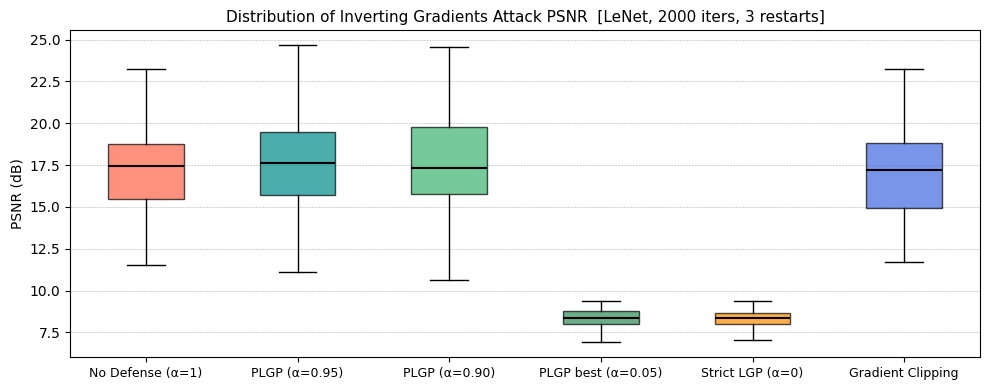

In [2]:
data, labels, colors = [], [], []
for method, alpha, label, color in CONDITIONS:
    r = results[(method, alpha)]
    if r['n'] > 0:
        data.append(r['psnr'])
        labels.append(label)
        colors.append(color)

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=FS-1)
ax.set_ylabel('PSNR (dB)', fontsize=FS)
ax.set_title('Distribution of Inverting Gradients Attack PSNR  [LeNet, 2000 iters, 3 restarts]', fontsize=FS+1)
ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
ax.tick_params(axis='y', labelsize=FS)
plt.tight_layout()
plt.show()

## SSIM Distribution per Defence Condition

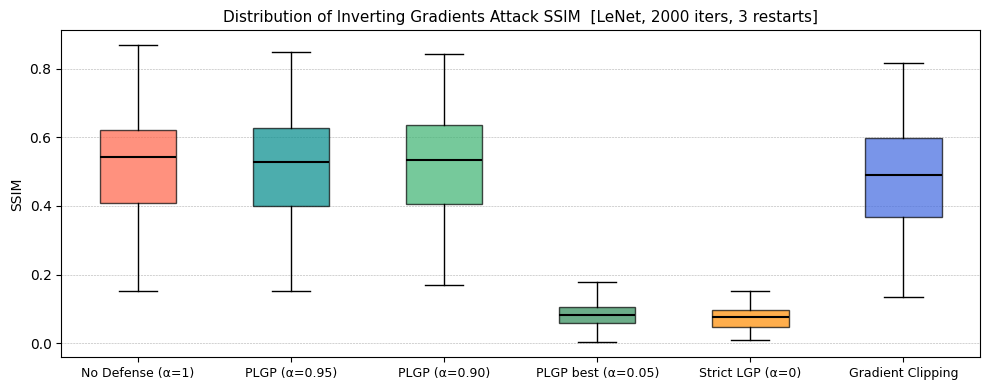

In [3]:
data_s, labels_s, colors_s = [], [], []
for method, alpha, label, color in CONDITIONS:
    r = results[(method, alpha)]
    if r['n'] > 0:
        data_s.append(r['ssim'])
        labels_s.append(label)
        colors_s.append(color)

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(data_s, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors_s):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(labels_s) + 1))
ax.set_xticklabels(labels_s, fontsize=FS-1)
ax.set_ylabel('SSIM', fontsize=FS)
ax.set_title('Distribution of Inverting Gradients Attack SSIM  [LeNet, 2000 iters, 3 restarts]', fontsize=FS+1)
ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
ax.tick_params(axis='y', labelsize=FS)
plt.tight_layout()
plt.show()

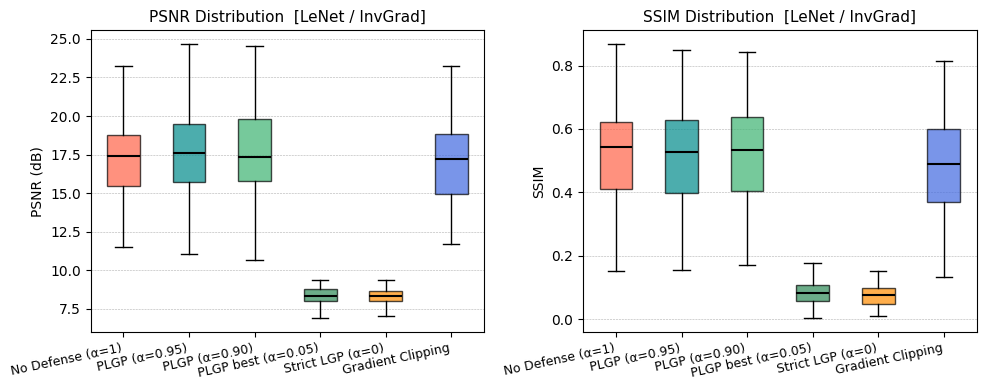

Saved figures/invgrad_lenet_psnr_ssim_boxplot.pdf


In [4]:
data_p, data_s, labels, colors = [], [], [], []
for method, alpha, label, color in CONDITIONS:
    r = results[(method, alpha)]
    if r['n'] > 0:
        data_p.append(r['psnr'])
        data_s.append(r['ssim'])
        labels.append(label)
        colors.append(color)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, ylabel, title in [
    (ax1, data_p, 'PSNR (dB)', 'PSNR Distribution  [LeNet / InvGrad]'),
    (ax2, data_s, 'SSIM',      'SSIM Distribution  [LeNet / InvGrad]'),
]:
    bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=FS - 1, rotation=12, ha='right')
    ax.set_ylabel(ylabel, fontsize=FS)
    ax.set_title(title, fontsize=FS + 1)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
    ax.tick_params(axis='y', labelsize=FS)

plt.tight_layout()
import os; os.makedirs("figures", exist_ok=True)
plt.savefig("figures/invgrad_lenet_psnr_ssim_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/invgrad_lenet_psnr_ssim_boxplot.pdf")

## Mean PSNR & SSIM per Condition (bar chart)

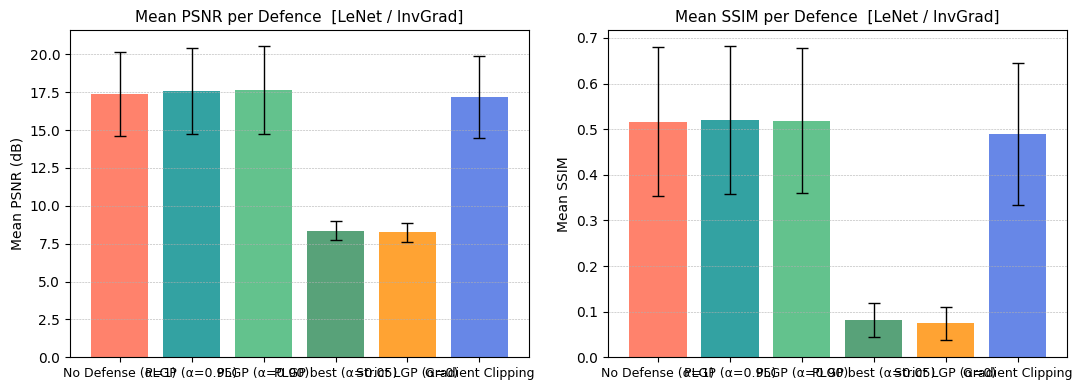

In [5]:
cond_labels, means_p, stds_p, means_s, stds_s, bar_colors = [], [], [], [], [], []
for method, alpha, label, color in CONDITIONS:
    r = results[(method, alpha)]
    if r['n'] > 0:
        cond_labels.append(label)
        means_p.append(np.nanmean(r['psnr']))
        stds_p.append(np.nanstd(r['psnr']))
        means_s.append(np.nanmean(r['ssim']))
        stds_s.append(np.nanstd(r['ssim']))
        bar_colors.append(color)

x = np.arange(len(cond_labels))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(x, means_p, yerr=stds_p, color=bar_colors, alpha=0.8,
            capsize=4, error_kw=dict(linewidth=1))
axes[0].set_xticks(x)
axes[0].set_xticklabels(cond_labels, fontsize=FS-1)
axes[0].set_ylabel('Mean PSNR (dB)', fontsize=FS)
axes[0].set_title('Mean PSNR per Defence  [LeNet / InvGrad]', fontsize=FS+1)
axes[0].grid(True, axis='y', linestyle='--', linewidth=0.4)
axes[0].tick_params(axis='y', labelsize=FS)

axes[1].bar(x, means_s, yerr=stds_s, color=bar_colors, alpha=0.8,
            capsize=4, error_kw=dict(linewidth=1))
axes[1].set_xticks(x)
axes[1].set_xticklabels(cond_labels, fontsize=FS-1)
axes[1].set_ylabel('Mean SSIM', fontsize=FS)
axes[1].set_title('Mean SSIM per Defence  [LeNet / InvGrad]', fontsize=FS+1)
axes[1].grid(True, axis='y', linestyle='--', linewidth=0.4)
axes[1].tick_params(axis='y', labelsize=FS)

plt.tight_layout()
plt.show()

## Label Inference Accuracy per Defence Condition
The attack also attempts to infer the true label from the gradient. This shows how well it succeeds under each defence.

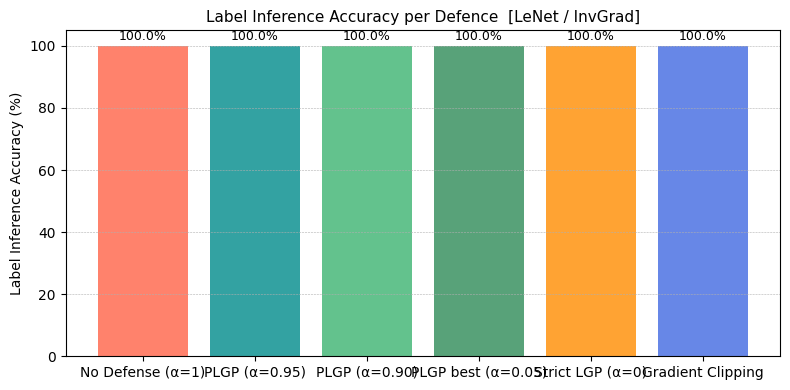

In [6]:
cond_labels2, label_accs, bar_colors2 = [], [], []
for method, alpha, label, color in CONDITIONS:
    r = results[(method, alpha)]
    if r['n'] > 0:
        cond_labels2.append(label)
        label_accs.append(np.mean(r['label_ok']) * 100)
        bar_colors2.append(color)

x2 = np.arange(len(cond_labels2))
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(x2, label_accs, color=bar_colors2, alpha=0.8)
ax.set_xticks(x2)
ax.set_xticklabels(cond_labels2, fontsize=FS-1)
ax.set_ylabel('Label Inference Accuracy (%)', fontsize=FS)
ax.set_title('Label Inference Accuracy per Defence  [LeNet / InvGrad]', fontsize=FS+1)
ax.set_ylim(0, 105)
ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
ax.tick_params(labelsize=FS)
for bar, val in zip(bars, label_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=FS-1)
plt.tight_layout()
plt.show()

## ViT â€” Inverting Gradients Attack (seed=10)
Loads `invgrad_hpc_export.json`. ViT was evaluated on seed=10 only (N=30 images per condition).

In [7]:
import os

# Load HPC export which contains ViT results
hpc_path = "invgrad_hpc_export.json"
vit_json = {}
if os.path.exists(hpc_path):
    with open(hpc_path) as f:
        vit_json = json.load(f)
    print(f"Loaded {len(vit_json)} entries from {hpc_path}")
else:
    print(f"WARNING: {hpc_path} not found")

VIT_CONDITIONS = [
    ("prune", 1.00, "No Defense (α=1)",    "tomato"),
    ("prune", 0.95, "PLGP (α=0.95)",       "darkcyan"),
    ("prune", 0.90, "PLGP (α=0.90)",       "mediumseagreen"),
    ("prune", 0.05, "PLGP best (α=0.05)",  "seagreen"),
    ("prune", 0.00, "Strict LGP (α=0)",    "darkorange"),
    ("clip",  1.00, "Gradient Clipping",   "royalblue"),
]
VIT_SEED     = 10
VIT_N_IMAGES = 30

def load_vit_condition(method, alpha):
    psnr_vals, ssim_vals, mse_vals, label_correct = [], [], [], []
    for img in range(VIT_N_IMAGES):
        key = (f"img_{img}_seed_{VIT_SEED}_alpha_{alpha:.2f}_"
               f"method_{method}_model_vit_iters_2000_restarts_3")
        entry = vit_json.get(key)
        if entry is None:
            continue
        psnr_vals.append(entry["psnr"])
        ssim_vals.append(entry["ssim"])
        mse_vals.append(entry["mse"])
        if "label_pred" in entry and "label_true" in entry:
            label_correct.append(int(entry["label_pred"] == entry["label_true"]))
    return np.array(psnr_vals), np.array(ssim_vals), np.array(mse_vals), np.array(label_correct)

vit_results = {}
for method, alpha, label, color in VIT_CONDITIONS:
    psnr, ssim, mse, label_ok = load_vit_condition(method, alpha)
    vit_results[(method, alpha)] = dict(
        label=label, color=color, psnr=psnr, ssim=ssim, mse=mse,
        label_ok=label_ok, n=len(psnr)
    )
    if len(psnr) > 0:
        acc_str = f"  LabelAcc={np.mean(label_ok)*100:.1f}%" if len(label_ok) > 0 else ""
        print(f"{label:25s}  n={len(psnr):3d}  "
              f"PSNR={np.nanmean(psnr):.2f}±{np.nanstd(psnr):.2f}  "
              f"SSIM={np.nanmean(ssim):.3f}{acc_str}")
    else:
        print(f"{label:25s}  NO DATA")


Loaded 631 entries from invgrad_hpc_export.json
No Defense (α=1)           n= 30  PSNR=9.55±1.04  SSIM=0.019  LabelAcc=0.0%
PLGP (α=0.95)              n= 30  PSNR=9.70±1.43  SSIM=0.022  LabelAcc=0.0%
PLGP (α=0.90)              n= 30  PSNR=9.66±1.31  SSIM=0.028  LabelAcc=0.0%
PLGP best (α=0.05)         n= 30  PSNR=9.97±1.10  SSIM=0.037  LabelAcc=0.0%
Strict LGP (α=0)           n= 30  PSNR=10.30±1.43  SSIM=0.046  LabelAcc=10.0%
Gradient Clipping          n= 30  PSNR=9.43±1.11  SSIM=0.018  LabelAcc=0.0%


### ViT: Mean PSNR & SSIM per Defence Condition

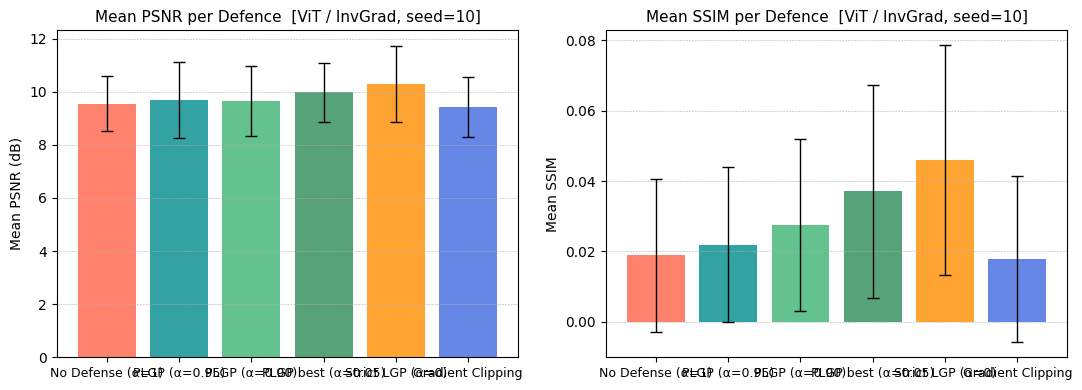

In [8]:
import os
os.makedirs("figures", exist_ok=True)

vit_labels, vit_mp, vit_sp, vit_ms, vit_ss, vit_colors = [], [], [], [], [], []
for method, alpha, label, color in VIT_CONDITIONS:
    r = vit_results[(method, alpha)]
    if r["n"] > 0:
        vit_labels.append(label)
        vit_mp.append(np.nanmean(r["psnr"]))
        vit_sp.append(np.nanstd(r["psnr"]))
        vit_ms.append(np.nanmean(r["ssim"]))
        vit_ss.append(np.nanstd(r["ssim"]))
        vit_colors.append(color)

xv = np.arange(len(vit_labels))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(xv, vit_mp, yerr=vit_sp, color=vit_colors, alpha=0.8,
            capsize=4, error_kw=dict(linewidth=1))
axes[0].set_xticks(xv)
axes[0].set_xticklabels(vit_labels, fontsize=FS-1)
axes[0].set_ylabel("Mean PSNR (dB)", fontsize=FS)
axes[0].set_title("Mean PSNR per Defence  [ViT / InvGrad, seed=10]", fontsize=FS+1)
axes[0].grid(True, axis="y", linestyle="--", linewidth=0.4)
axes[0].tick_params(axis="y", labelsize=FS)

axes[1].bar(xv, vit_ms, yerr=vit_ss, color=vit_colors, alpha=0.8,
            capsize=4, error_kw=dict(linewidth=1))
axes[1].set_xticks(xv)
axes[1].set_xticklabels(vit_labels, fontsize=FS-1)
axes[1].set_ylabel("Mean SSIM", fontsize=FS)
axes[1].set_title("Mean SSIM per Defence  [ViT / InvGrad, seed=10]", fontsize=FS+1)
axes[1].grid(True, axis="y", linestyle="--", linewidth=0.4)
axes[1].tick_params(axis="y", labelsize=FS)

plt.tight_layout()
plt.savefig("figures/invgrad_vit_psnr_ssim.pdf", dpi=300, bbox_inches="tight")
plt.show()


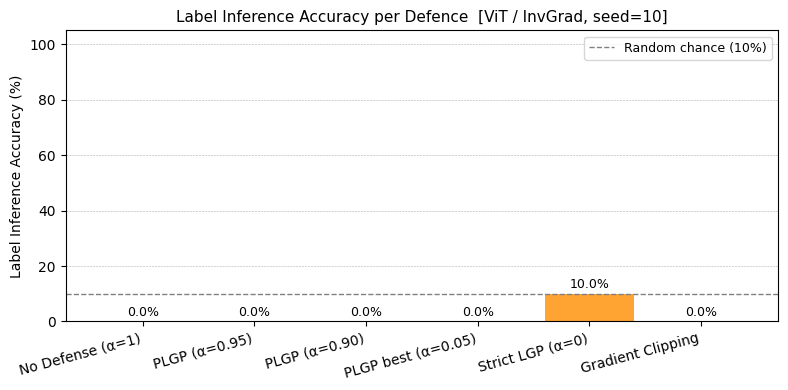

Saved figures/invgrad_vit_label_accuracy.pdf


In [9]:
vit_label_labels, vit_label_accs, vit_label_colors = [], [], []
for method, alpha, label, color in VIT_CONDITIONS:
    r = vit_results[(method, alpha)]
    if r["n"] > 0 and len(r["label_ok"]) > 0:
        vit_label_labels.append(label)
        vit_label_accs.append(np.mean(r["label_ok"]) * 100)
        vit_label_colors.append(color)

xv2 = np.arange(len(vit_label_labels))
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(xv2, vit_label_accs, color=vit_label_colors, alpha=0.8)
ax.axhline(10, color='gray', linestyle='--', linewidth=1, label='Random chance (10%)')
ax.set_xticks(xv2)
ax.set_xticklabels(vit_label_labels, fontsize=FS-1, rotation=15, ha='right')
ax.set_ylabel('Label Inference Accuracy (%)', fontsize=FS)
ax.set_title('Label Inference Accuracy per Defence  [ViT / InvGrad, seed=10]', fontsize=FS+1)
ax.set_ylim(0, 105)
ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
ax.tick_params(labelsize=FS)
ax.legend(fontsize=FS-1)
for bar, val in zip(bars, vit_label_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=FS-1)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/invgrad_vit_label_accuracy.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/invgrad_vit_label_accuracy.pdf")


### LeNet vs ViT Side-by-Side Comparison

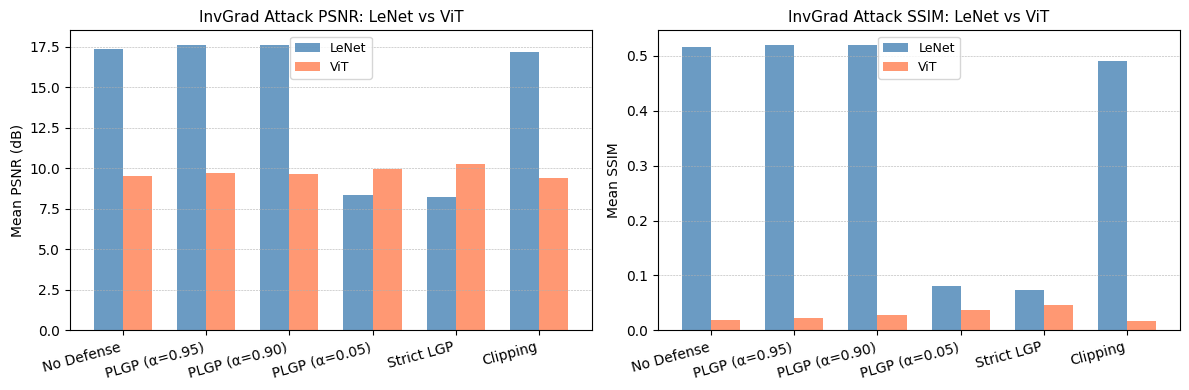

In [10]:
SHARED = [
    ("prune", 1.00, "No Defense",      "tomato"),
    ("prune", 0.95, "PLGP (α=0.95)", "darkcyan"),
    ("prune", 0.90, "PLGP (α=0.90)", "mediumseagreen"),
    ("prune", 0.05, "PLGP (α=0.05)", "seagreen"),
    ("prune", 0.00, "Strict LGP",      "darkorange"),
    ("clip",  1.00, "Clipping",         "royalblue"),
]

lenet_p, lenet_s, vit_p2, vit_s2, shared_labels = [], [], [], [], []
for method, alpha, label, _ in SHARED:
    lr = results.get((method, alpha))
    vr = vit_results.get((method, alpha))
    if lr and lr["n"] > 0 and vr and vr["n"] > 0:
        lenet_p.append(np.nanmean(lr["psnr"]))
        lenet_s.append(np.nanmean(lr["ssim"]))
        vit_p2.append(np.nanmean(vr["psnr"]))
        vit_s2.append(np.nanmean(vr["ssim"]))
        shared_labels.append(label)

x = np.arange(len(shared_labels))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x - w/2, lenet_p, w, label="LeNet", color="steelblue", alpha=0.8)
axes[0].bar(x + w/2, vit_p2,  w, label="ViT",   color="coral",     alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(shared_labels, fontsize=FS-1, rotation=15, ha='right')
axes[0].set_ylabel("Mean PSNR (dB)", fontsize=FS)
axes[0].set_title("InvGrad Attack PSNR: LeNet vs ViT", fontsize=FS+1)
axes[0].legend(fontsize=FS-1)
axes[0].grid(True, axis="y", linestyle="--", linewidth=0.4)
axes[0].tick_params(labelsize=FS)

axes[1].bar(x - w/2, lenet_s, w, label="LeNet", color="steelblue", alpha=0.8)
axes[1].bar(x + w/2, vit_s2,  w, label="ViT",   color="coral",     alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(shared_labels, fontsize=FS-1, rotation=15, ha='right')
axes[1].set_ylabel("Mean SSIM", fontsize=FS)
axes[1].set_title("InvGrad Attack SSIM: LeNet vs ViT", fontsize=FS+1)
axes[1].legend(fontsize=FS-1)
axes[1].grid(True, axis="y", linestyle="--", linewidth=0.4)
axes[1].tick_params(labelsize=FS)

plt.tight_layout()
plt.savefig("figures/invgrad_lenet_vs_vit.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Privacy-Utility Tradeoff: SSIM vs Defence Strength
Two SSIM curves (iDLG and InvGrad on LeNet) and two accuracy curves (LeNet and ViT) against defence condition.

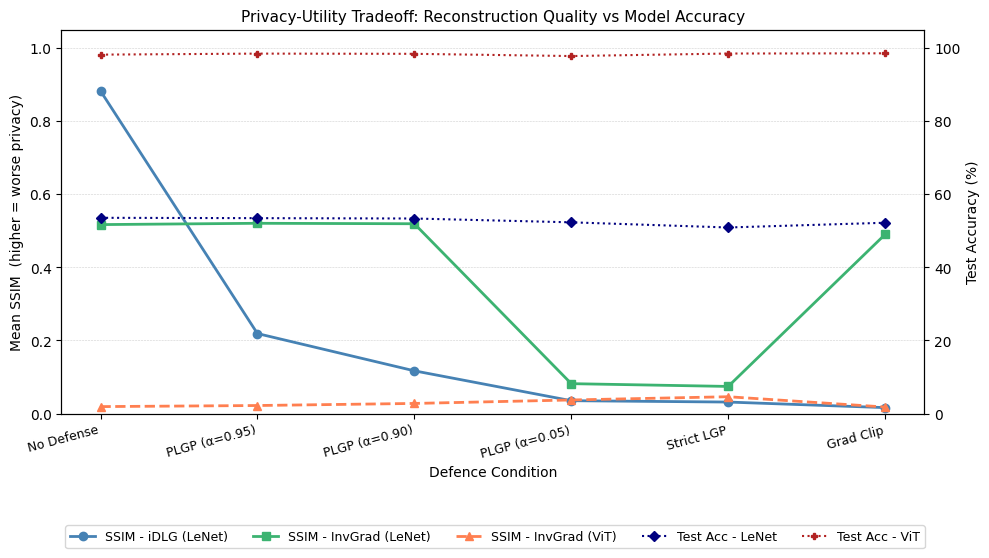

Saved figures/privacy_utility_tradeoff.pdf


In [11]:
import pandas as pd

df = pd.read_csv('results/summary.csv')

TRADEOFF_CONDITIONS = [
    ('prune', 1.00, 'No Defense'),
    ('prune', 0.95, 'PLGP (α=0.95)'),
    ('prune', 0.90, 'PLGP (α=0.90)'),
    ('prune', 0.05, 'PLGP (α=0.05)'),
    ('prune', 0.00, 'Strict LGP'),
    ('clip',  1.00, 'Grad Clip'),
]

lenet_df = df[df.model == 'lenet']
vit_df   = df[df.model == 'vit']

xlabels, idlg_ssim, invg_ssim_ln, invg_ssim_vt, lenet_acc, vit_acc = [], [], [], [], [], []

for method, alpha, lbl in TRADEOFF_CONDITIONS:
    row_ln = lenet_df[(lenet_df.method == method) & (lenet_df.alpha == alpha)]
    row_vt = vit_df[(vit_df.method == method) & (vit_df.alpha == alpha)]
    if row_ln.empty:
        continue
    xlabels.append(lbl)
    idlg_ssim.append(row_ln["idlg_ssim"].mean())
    invg_ssim_ln.append(row_ln["invgrad_ssim"].mean())
    lenet_acc.append(row_ln["test_acc"].mean() * 100)
    invg_ssim_vt.append(row_vt["invgrad_ssim"].mean() if not row_vt.empty else float("nan"))
    vit_acc.append(row_vt["test_acc"].mean() * 100 if not row_vt.empty else float("nan"))

x = np.arange(len(xlabels))
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(x, idlg_ssim,    "o-",  color="steelblue",      lw=2, ms=6, label="SSIM - iDLG (LeNet)")
ax1.plot(x, invg_ssim_ln, "s-",  color="mediumseagreen", lw=2, ms=6, label="SSIM - InvGrad (LeNet)")
ax1.plot(x, invg_ssim_vt, "^--", color="coral",          lw=2, ms=6, label="SSIM - InvGrad (ViT)")
ax1.set_ylabel("Mean SSIM  (higher = worse privacy)", fontsize=FS)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis="y", labelsize=FS)

ax2.plot(x, lenet_acc, "D:",  color="navy",      lw=1.5, ms=5, label="Test Acc - LeNet")
ax2.plot(x, vit_acc,   "P:",  color="firebrick", lw=1.5, ms=5, label="Test Acc - ViT")
ax2.set_ylabel("Test Accuracy (%)", fontsize=FS)
ax2.set_ylim(0, 105)
ax2.tick_params(axis="y", labelsize=FS)

ax1.set_xticks(x)
ax1.set_xticklabels(xlabels, fontsize=FS-1, rotation=15, ha="right")
ax1.set_xlabel("Defence Condition", fontsize=FS)
ax1.set_title("Privacy-Utility Tradeoff: Reconstruction Quality vs Model Accuracy", fontsize=FS+1)
ax1.grid(True, axis="y", linestyle="--", lw=0.4, alpha=0.6)

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labs1 + labs2, fontsize=FS-1,
           loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/privacy_utility_tradeoff.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/privacy_utility_tradeoff.pdf")
